# Xenium to SpatialData zarr

This is the flagship conversion: turning a raw 10x Xenium output directory into a [SpatialData](https://spatialdata.scverse.org/en/stable/) zarr store, with an aligned H&E image, tissue segmentation, and Visium-like pseudo-spots at whatever sizes you need.

**What you need:** a Xenium output directory (see [Downloading Xenium data](xenium_download)) containing `experiment.xenium` and the associated transcript/cell/boundary files, optionally with an aligned H&E image and alignment CSV. **Runtime:** minutes to tens of minutes depending on dataset size and `n_jobs`; the zarr store is written incrementally, so memory stays bounded even for large panels.

In [1]:
from pathlib import Path

import dask
import spatialdata as sd

from spatialrefinery import xenium_to_spatialdata, xenium_to_spatialdata_zip

# Xenium's dask-backed transcript tables are large; disable dask's query planner
# to avoid excessive memory use while building the task graph for a full panel.
dask.config.set({"dataframe.query-planning": False})

/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/spatialrefinery/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

Edit these to point at your own data. `DATASET_PATH` is a single Xenium output directory (one biospecimen); `OUTPUT_PATH` is where the zarr store (and, later, the zip archive) will be written.

In [2]:
DATASET_PATH = Path(
    "/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/tenx/Xenium_V1_hKidney_cancer_section"
)
OUTPUT_PATH = Path("/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/example_zarr_files")
OUTPUT_NAME = "Xenium_V1_hKidney_cancer"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

## Convert to a zarr store

`xenium_to_spatialdata` loads the transcripts, cell and nucleus boundaries, and (if available) the aligned H&E image with its own tissue segmentation, writing the result to `OUTPUT_PATH/OUTPUT_NAME.zarr`. Passing `spot_sizes` creates pseudo-spots in the same pass -- note that spots are only created when *both* `create_spots=True` **and** `spot_sizes` is a non-empty list; leaving `spot_sizes=None` (the default) skips spot creation entirely even with `create_spots=True`.

In [3]:
zarr_path = xenium_to_spatialdata(
    dataset_path=DATASET_PATH,
    output_path=OUTPUT_PATH,
    output_name=OUTPUT_NAME,
    include_aligned_image=True,
    create_spots=True,
    spot_sizes=[55, 100],
    overlap=0.06,
    values="transcripts",
    n_jobs=8,
)
zarr_path

INFO     Processing Xenium dataset: Xenium_V1_hKidney_cancer_section                                               
INFO     Loading Xenium data...                                                                                    
INFO     Writing base data to                                                                                      
         /Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/example_zarr_files/Xenium_V1_hKid
         ney_cancer.zarr...                                                                                        


/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/spatialrefinery/.venv/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:477: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Adding aligned H&E image...                                                                               


no parent found for <ome_zarr.reader.Label object at 0x3113e0080>: None
no parent found for <ome_zarr.reader.Label object at 0x1662406b0>: None


INFO     H&E image added successfully                                                                              
INFO     H&E Tissue Contours added successfully                                                                    
INFO     Creating pseudo-spots iteratively...                                                                      


...

/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/spatialrefinery/src/spatialrefinery/io/xenium.py:169: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  aggr_sdata["table"].obsm["spatial"] = aggr_sdata[f"spots_{spot_size_um!s}um"][["x_um", "y_um"]].values


INFO     Updating sdata with table element for spots of size 55µm...                                               
INFO     Processing spot size: 100µm                                                                               
INFO     Created 3366 hexagonal pseudo-spots of size 100µm with 6.0% overlap                                       
INFO     Updating sdata with shape element for spots of size 100µm...                                              


/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/spatialrefinery/src/spatialrefinery/io/xenium.py:169: ImplicitModificationWarning: Setting element `.obsm['spatial']` of view, initializing view as actual.
  aggr_sdata["table"].obsm["spatial"] = aggr_sdata[f"spots_{spot_size_um!s}um"][["x_um", "y_um"]].values


INFO     Updating sdata with table element for spots of size 100µm...                                              
INFO     Successfully created                                                                                      
         /Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/example_zarr_files/Xenium_V1_hKid
         ney_cancer.zarr                                                                                           


PosixPath('/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/example_zarr_files/Xenium_V1_hKidney_cancer.zarr')

## Inspect the result

Reading the store back with `spatialdata.read_zarr` shows every element it contains -- images, labels, points, shapes, and tables:

In [4]:
sdata = sd.read_zarr(zarr_path)
sdata

no parent found for <ome_zarr.reader.Label object at 0x31136cd70>: None
no parent found for <ome_zarr.reader.Label object at 0x16a22a8d0>: None


SpatialData object, with associated Zarr store: /Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/example_zarr_files/Xenium_V1_hKidney_cancer.zarr
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 27323, 8832), (3, 13661, 4416), (3, 6830, 2208)
│     └── 'morphology_mip': DataTree[cyx] (1, 10346, 36943), (1, 5173, 18471), (1, 2586, 9235), (1, 1293, 4617), (1, 646, 2308)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (10346, 36943), (5173, 18471), (2586, 9235), (1293, 4617), (646, 2308)
│     └── 'nucleus_labels': DataTree[yx] (10346, 36943), (5173, 18471), (2586, 9235), (1293, 4617), (646, 2308)
├── Points
│     └── 'transcripts': DataFrame with shape: (5115684, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (56510, 1) (2D shapes)
│     ├── 'nucleus_boundaries': GeoDataFrame shape: (56510, 1) (2D shapes)
│     ├── 'spots_55um': GeoDataFrame shape: (10502, 3) (2D shapes)
│     ├── 'spots_100um': GeoDataFrame shape: (3366, 3) (2D sha

no parent found for <ome_zarr.reader.Label object at 0x16a22b530>: None
no parent found for <ome_zarr.reader.Label object at 0x166688290>: None


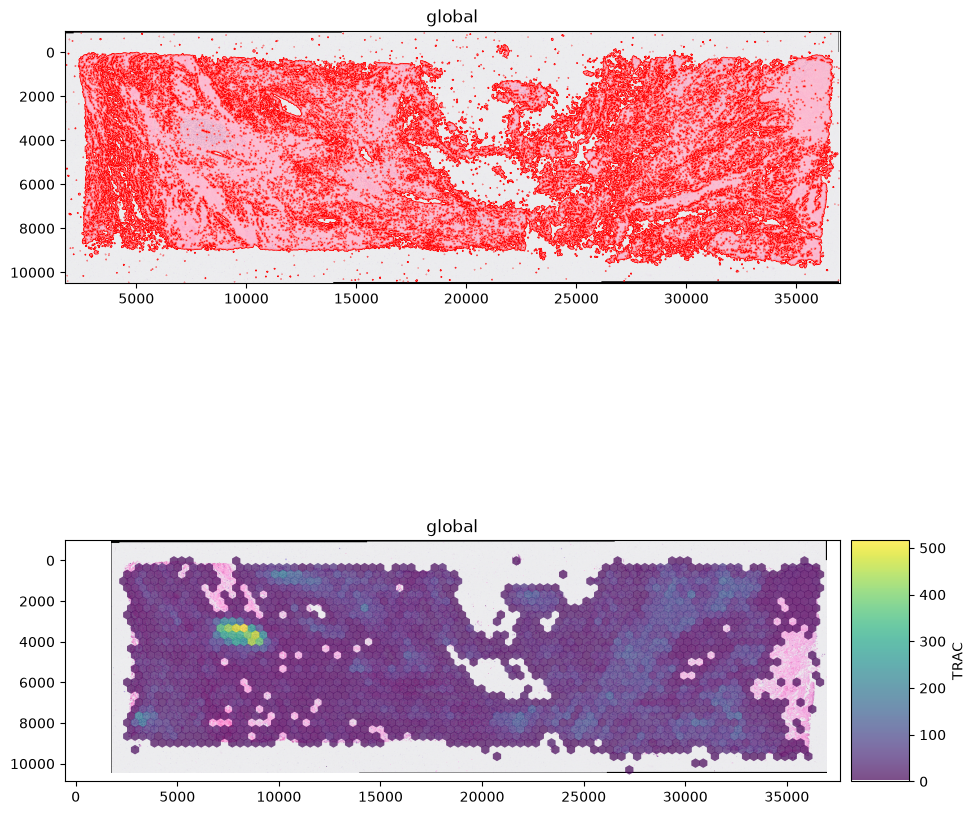

In [7]:
import matplotlib.pyplot as plt
from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent

sdata = sd.read_zarr(zarr_path)

fig, axs = plt.subplots(2, 1, figsize=(10, 12))

new_cmap = set_zero_in_cmap_to_transparent(cmap="viridis")
# # new_cmap = "viridis"
sdata.pl.render_images("he_image").pl.render_shapes(
    "tissue_contours", color="pink", fill_alpha=0.7, outline_width=1.0, outline_alpha=1.0, outline_color="red"
).pl.show(ax=axs[0])

sdata.pl.render_images("he_image").pl.render_shapes("spots_100um", color="TRAC", cmap=new_cmap, fill_alpha=0.7).pl.show(
    ax=axs[1]
)

## Pseudo-spot parameters

- `spot_sizes` -- spot diameters in micrometers; one `spots_<size>um` shape element (and matching `spots_<size>um_table` AnnData) is created per size.
- `overlap` -- fractional overlap between adjacent hexagonal spots (`0.0` = no overlap, i.e. spots tile the plane; higher values oversample the boundary between spots).
- `values` -- what gets aggregated into each spot: `"transcripts"` (default) or `"cell_boundaries"`.

## Packaging for transfer: `xenium_to_spatialdata_zip`

Same conversion, plus a zip archive of the zarr directory -- convenient for moving a sample between machines. `keep_zarr=False` removes the unzipped directory afterwards to save disk space.

In [ ]:
zip_path = xenium_to_spatialdata_zip(
    dataset_path=DATASET_PATH,
    output_path=OUTPUT_PATH,
    output_name=OUTPUT_NAME,
    include_aligned_image=True,
    create_spots=True,
    spot_sizes=[55, 100],
    overlap=0.06,
    n_jobs=8,
    keep_zarr=True,
    overwrite=False,
)
print(f"Created {zip_path} ({zip_path.stat().st_size / 1024**3:.2f} GB)")

## Expected output structure

```text
example_study.zarr
├── Images
│   └── 'he_image': DataTree[cyx] (3, 27502, 14896), (3, 13751, 7448), (3, 6875, 3724)
├── Labels
│   ├── 'cell_labels': DataTree[yx] ...
│   └── 'nucleus_labels': DataTree[yx] ...
├── Points
│   └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│   ├── 'cell_boundaries': GeoDataFrame shape: (140702, 1) (2D shapes)
│   ├── 'cell_circles': GeoDataFrame shape: (140702, 2) (2D shapes)
│   ├── 'nucleus_boundaries': GeoDataFrame shape: (136531, 1) (2D shapes)
│   ├── 'spots_55um': GeoDataFrame shape: (6705, 3) (2D shapes)
│   └── 'spots_100um': GeoDataFrame shape: (2086, 3) (2D shapes)
└── Tables
    ├── 'spots_55um_table': AnnData (6705, 377)
    ├── 'spots_100um_table': AnnData (2086, 377)
    └── 'table': AnnData (140702, 377)
```

## Batch processing multiple samples

`xenium_to_spatialdata` is safe to call in a loop over a directory of Xenium output directories -- each sample's failure is independent of the others:

In [ ]:
raw_data_dir = Path("/Users/rushin.gindra/Documents/Research/SpatialProjects/Phoenix/datasets/tenx")

for sample_dir in raw_data_dir.iterdir():
    if not sample_dir.is_dir():
        continue
    try:
        xenium_to_spatialdata(dataset_path=sample_dir, output_path=OUTPUT_PATH, n_jobs=8)
        print(f"Processed {sample_dir.name}")
    except Exception as e:  # noqa: BLE001 - one sample's failure must not abort the batch
        print(f"Failed to process {sample_dir.name}: {e}")

## Running this as a script

```bash
python scripts/xenium_to_zarr.py \
    --data-path raw_files \
    --biospecimen-id example_study \
    --output-path processed \
    --num-workers 8
```

## What's next

Continue to {doc}`Converting images to OME-TIFF <convert_to_ometiff>` to prepare a companion whole-slide image for pyramidal viewing.